In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv("C:\\Users\\edson.sanchez\\OneDrive - ALTAN REDES\\Documentos Altan\\TripleTen\\vehicles_env\\vehicles_us.csv", encoding='utf-8')

In [65]:
df.head()

,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,2011.0,bmw x5,good,6.0,gas,145000.0,automatic,SUV,NaN,1.0,2018-06-23,19
1,25500,NaN,ford f-150,good,6.0,gas,88705.0,automatic,pickup,white,1.0,2018-10-19,50
2,5500,2013.0,hyundai sonata,like new,4.0,gas,110000.0,automatic,sedan,red,NaN,2019-02-07,79
3,1500,2003.0,ford f-150,fair,8.0,gas,NaN,automatic,pickup,NaN,NaN,2019-03-22,9
4,14900,2017.0,chrysler 200,excellent,4.0,gas,80903.0,automatic,sedan,black,NaN,2019-04-02,28


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  object 
 3   condition     51525 non-null  object 
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  object 
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  object 
 8   type          51525 non-null  object 
 9   paint_color   42258 non-null  object 
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  object 
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 5.1+ MB


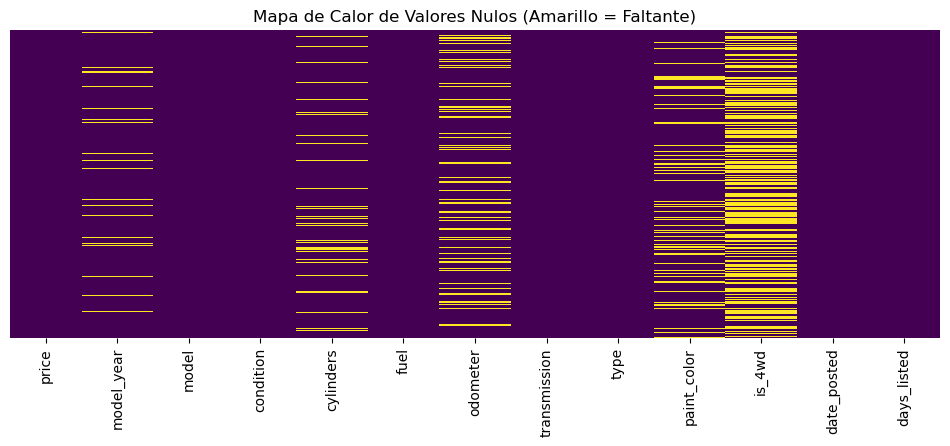

In [67]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de Calor de Valores Nulos (Amarillo = Faltante)')
plt.show()

In [68]:
#Corregir formatos y algunos valores nulos
df['model_year'] = df['model_year'].astype('Int64')

In [69]:
df['is_4wd'] = df['is_4wd'].fillna(0).astype('Int64')

In [70]:
df['date_posted'] = pd.to_datetime(df['date_posted'])

In [71]:
df['cylinders'] = df['cylinders'].astype('Int64')

In [72]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   price         51525 non-null  int64         
 1   model_year    47906 non-null  Int64         
 2   model         51525 non-null  object        
 3   condition     51525 non-null  object        
 4   cylinders     46265 non-null  Int64         
 5   fuel          51525 non-null  object        
 6   odometer      43633 non-null  float64       
 7   transmission  51525 non-null  object        
 8   type          51525 non-null  object        
 9   paint_color   42258 non-null  object        
 10  is_4wd        51525 non-null  Int64         
 11  date_posted   51525 non-null  datetime64[ns]
 12  days_listed   51525 non-null  int64         
dtypes: Int64(3), datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 5.3+ MB


,price,model_year,model,condition,cylinders,fuel,odometer,transmission,type,paint_color,is_4wd,date_posted,days_listed
0,9400,2011,bmw x5,good,6,gas,145000.0,automatic,SUV,NaN,1,2018-06-23,19
1,25500,<NA>,ford f-150,good,6,gas,88705.0,automatic,pickup,white,1,2018-10-19,50
2,5500,2013,hyundai sonata,like new,4,gas,110000.0,automatic,sedan,red,0,2019-02-07,79
3,1500,2003,ford f-150,fair,8,gas,NaN,automatic,pickup,NaN,0,2019-03-22,9
4,14900,2017,chrysler 200,excellent,4,gas,80903.0,automatic,sedan,black,0,2019-04-02,28


In [73]:
df.isnull().sum()

price              0
model_year      3619
model              0
condition          0
cylinders       5260
fuel               0
odometer        7892
transmission       0
type               0
paint_color     9267
is_4wd             0
date_posted        0
days_listed        0
dtype: int64

In [74]:
df.describe()

,price,model_year,cylinders,odometer,is_4wd,date_posted,days_listed
count,51525.000000,47906.0,46265.0,43633.000000,51525.0,51525,51525.00000
mean,12132.464920,2009.75047,6.125235,115553.461738,0.496303,2018-10-25 01:57:46.270742528,39.55476
min,1.000000,1908.0,3.0,0.000000,0.0,2018-05-01 00:00:00,0.00000
25%,5000.000000,2006.0,4.0,70000.000000,0.0,2018-07-29 00:00:00,19.00000
50%,9000.000000,2011.0,6.0,113000.000000,0.0,2018-10-25 00:00:00,33.00000
75%,16839.000000,2014.0,8.0,155000.000000,1.0,2019-01-21 00:00:00,53.00000
max,375000.000000,2019.0,12.0,990000.000000,1.0,2019-04-19 00:00:00,271.00000
std,10040.803015,6.282065,1.66036,65094.611341,0.499991,NaN,28.20427


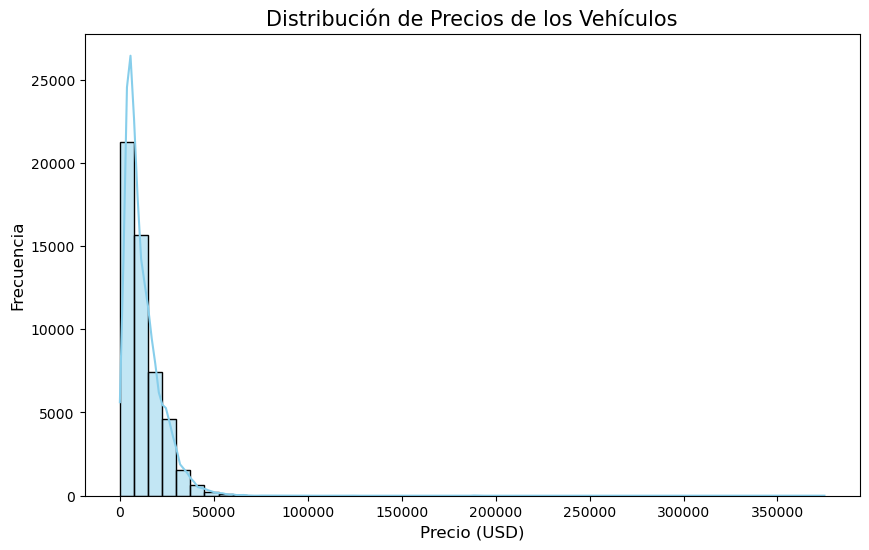

In [75]:
# Crear el histograma
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')

# Añadir títulos y etiquetas
plt.title('Distribución de Precios de los Vehículos', fontsize=15)
plt.xlabel('Precio (USD)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

plt.show()

C:\Users\edson.sanchez\AppData\Local\Temp\ipykernel_12560\3021967499.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='price', palette='Set2')


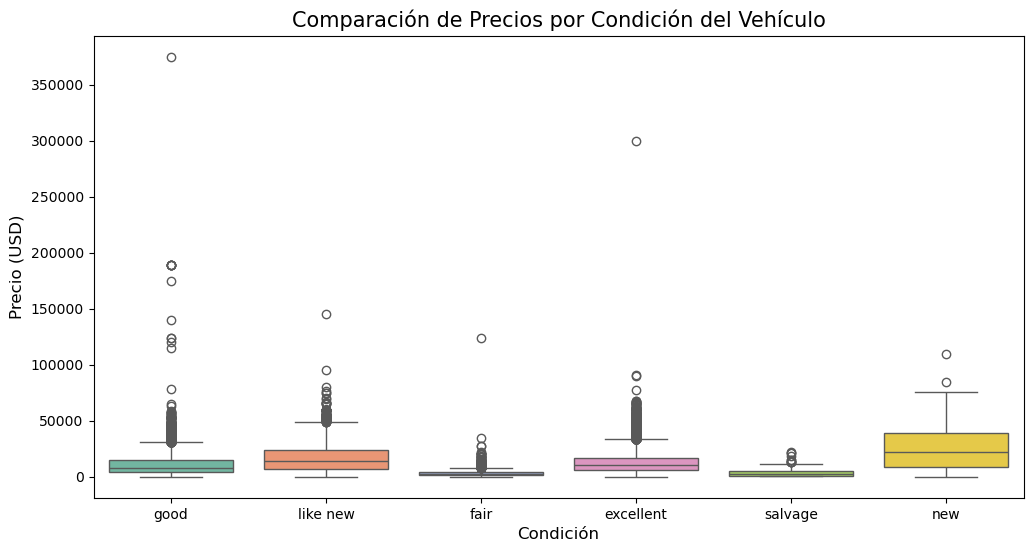

In [76]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Crear el boxplot: x para la categoría y 'y' para el valor numérico
sns.boxplot(data=df, x='condition', y='price', palette='Set2')

# Personalizar el gráfico
plt.title('Comparación de Precios por Condición del Vehículo', fontsize=15)
plt.xlabel('Condición', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)

plt.show()

C:\Users\edson.sanchez\AppData\Local\Temp\ipykernel_12560\3672047934.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['model'].isin(top_modelos)],


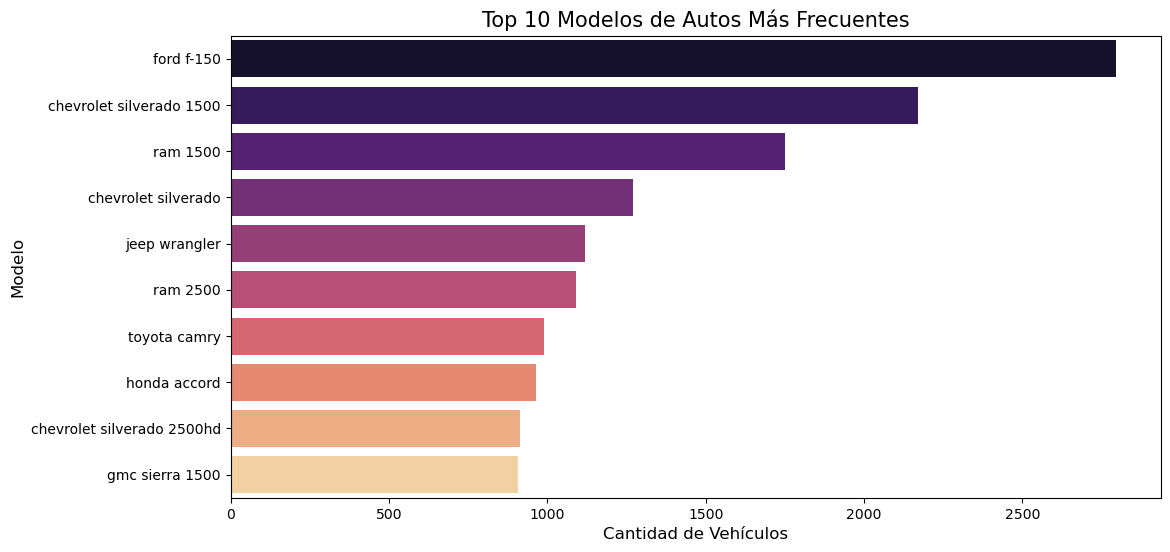

In [77]:
# 1. Obtener los 10 modelos más frecuentes
top_modelos = df['model'].value_counts().head(10).index

# 2. Configurar el gráfico
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['model'].isin(top_modelos)], 
              y='model', 
              order=top_modelos, 
              palette='magma')

# 3. Personalización
plt.title('Top 10 Modelos de Autos Más Frecuentes', fontsize=15)
plt.xlabel('Cantidad de Vehículos', fontsize=12)
plt.ylabel('Modelo', fontsize=12)

plt.show()

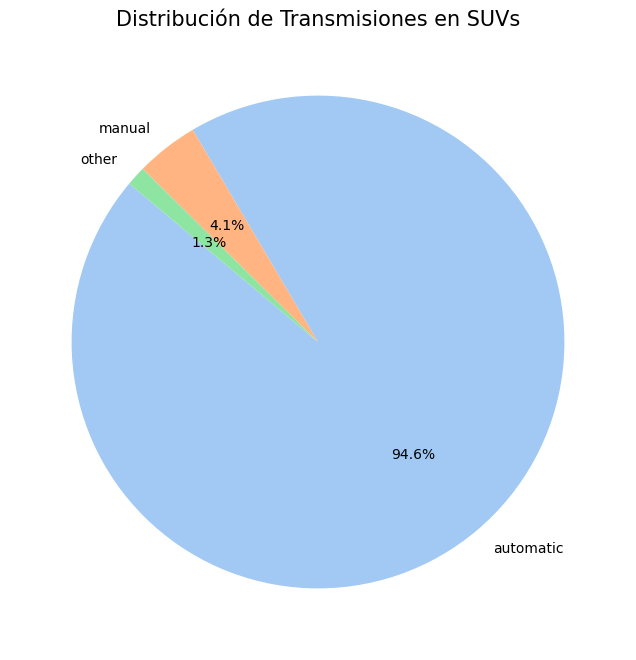

In [78]:
# 1. Filtramos el DataFrame para quedarnos solo con los SUVs
df_suv = df[df['type'].str.lower() == 'suv']

# 2. Calculamos las frecuencias de transmisión
transmision_counts = df_suv['transmission'].value_counts()

# 3. Creamos el gráfico de sectores (Pie Chart) para ver porcentajes directos
plt.figure(figsize=(8, 8))
plt.pie(transmision_counts, labels=transmision_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))

plt.title('Distribución de Transmisiones en SUVs', fontsize=15)
plt.show()

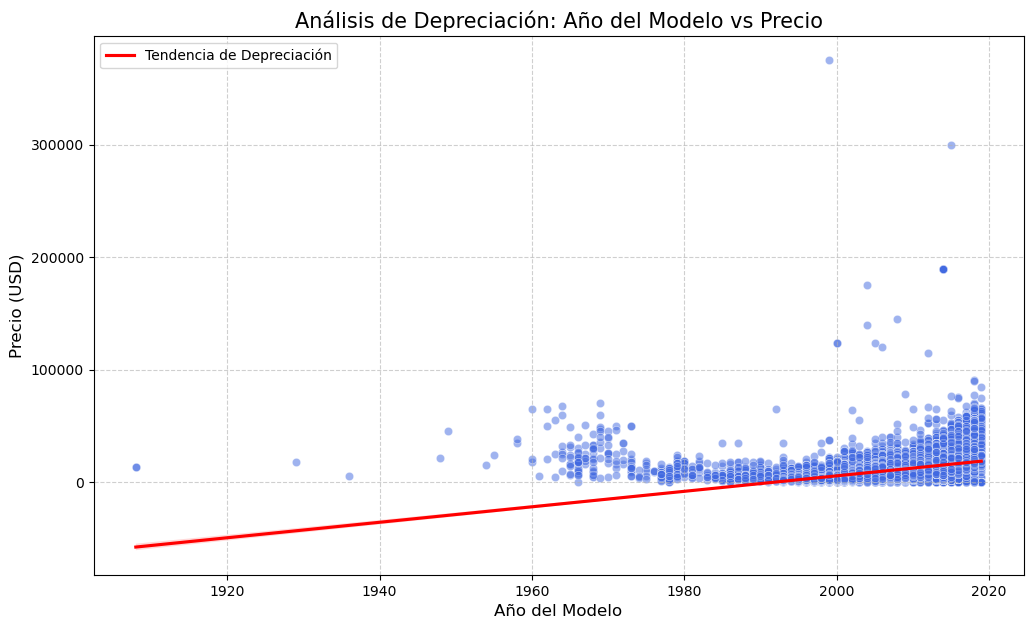

In [79]:
# Configuramos el gráfico
plt.figure(figsize=(12, 7))

# Creamos el scatter plot
# Agregamos 'alpha' para ver mejor los puntos amontonados
sns.scatterplot(data=df, x='model_year', y='price', alpha=0.5, color='royalblue')

# Opcional: Agregar una línea de tendencia (regresión) para ver la depreciación clara
sns.regplot(data=df, x='model_year', y='price', scatter=False, color='red', label='Tendencia de Depreciación')

# Personalización
plt.title('Análisis de Depreciación: Año del Modelo vs Precio', fontsize=15)
plt.xlabel('Año del Modelo', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

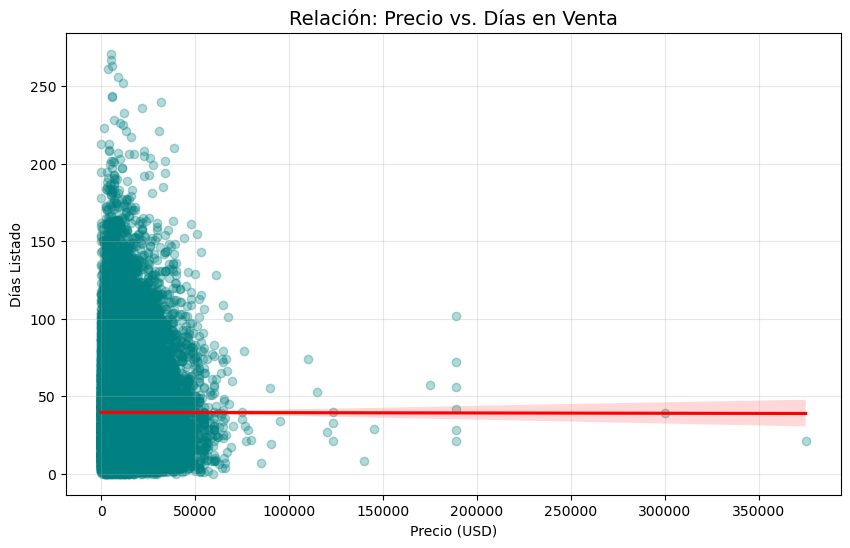

In [80]:
plt.figure(figsize=(10, 6))

# Usamos regplot para ver la tendencia de dispersión
sns.regplot(data=df, x='price', y='days_listed', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Relación: Precio vs. Días en Venta', fontsize=14)
plt.xlabel('Precio (USD)')
plt.ylabel('Días Listado')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\edson.sanchez\AppData\Local\Temp\ipykernel_12560\2826528022.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='paint_color', y='days_listed',
C:\Users\edson.sanchez\AppData\Local\Temp\ipykernel_12560\2826528022.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='paint_color', y='days_listed',


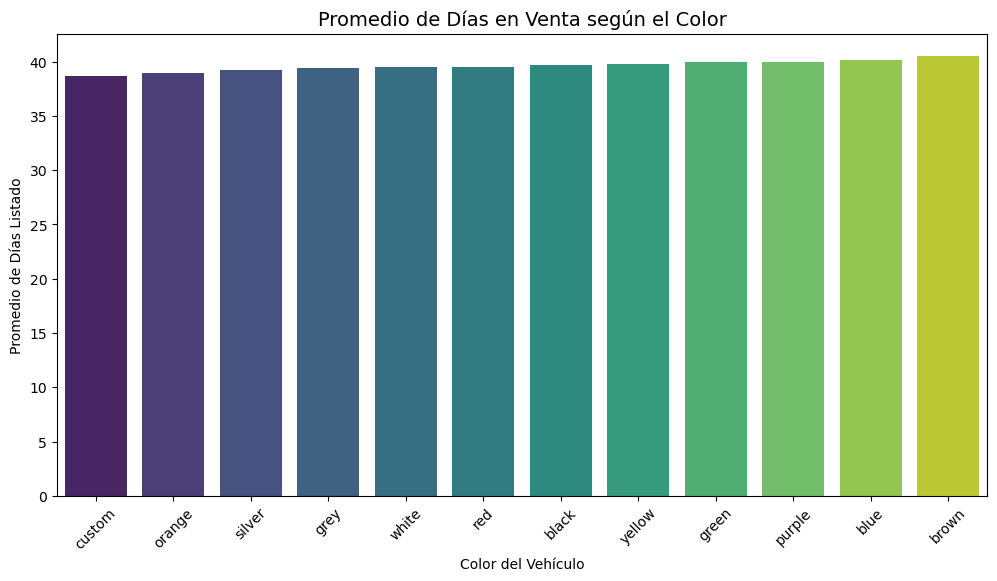

In [81]:
plt.figure(figsize=(12, 6))

# Calculamos el promedio de días listado por cada color
# Ordenamos de menor a mayor para ver cuál se vende "más rápido"
color_order = df.groupby('paint_color')['days_listed'].mean().sort_values().index

sns.barplot(data=df, x='paint_color', y='days_listed', 
            order=color_order, palette='viridis', ci=None)

plt.title('Promedio de Días en Venta según el Color', fontsize=14)
plt.xlabel('Color del Vehículo')
plt.ylabel('Promedio de Días Listado')
plt.xticks(rotation=45)
plt.show()